In [1]:
import pandas as pd
import numpy as np
import glob
from tqdm.auto import tqdm

import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import transforms
import pathlib
from torch.utils.data import DataLoader, TensorDataset
import torchvision
from torch.optim.lr_scheduler import ExponentialLR
from torchviz import make_dot

import pytorch_lightning as pl

import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
import matplotlib
from matplotlib.ticker import MaxNLocator

from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger
from torchmetrics.functional import accuracy

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

import datetime
import time
import random
import os


# setting device on GPU if available, else CPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

/home/lisa/anaconda3/envs/agg_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda:0

NVIDIA RTX A6000
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [ ]:
class LCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(LCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(8)
        self.relu = nn.ReLU(inplace=True)

        self.conv_pw1 = self.pointwise_conv(8, 16, stride=1)
        self.conv_pw2 = self.pointwise_conv(16, 32, stride=1)
        self.conv_pw3 = self.pointwise_conv(32, 64, stride=1)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, num_classes)  # Add fully connected layer

    def pointwise_conv(self, inp, oup, stride):
        return nn.Sequential(
            nn.Conv2d(inp, oup, 1, stride, 0, bias=False),  # Pointwise convolution
            nn.BatchNorm2d(oup),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv_pw1(x)
        x = self.conv_pw2(x)
        x = self.conv_pw3(x)

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [3]:
def load_and_concat_csv(path):
    """
    Load all CSV files from a directory and return a single concatenated DataFrame.
    """
    csv_files = glob.glob(os.path.join(path, "*.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {path}")

    df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
    return df

In [4]:
# Kia Aggressive Driving Data
Kia_Normal = load_and_concat_csv("/home/lisa/Arupreza/ADDS/Data/FedModel/AggKia/Normal/")
Kia_Break = load_and_concat_csv("/home/lisa/Arupreza/ADDS/Data/FedModel/AggKia/Break/")
Kia_Lane = load_and_concat_csv("/home/lisa/Arupreza/ADDS/Data/FedModel/AggKia/Lane/")
Kia_Speed = load_and_concat_csv("/home/lisa/Arupreza/ADDS/Data/FedModel/AggKia/Speed/")
# Kia Conventional Attack Driving Data
ConAttKia_Normal = load_and_concat_csv("/home/lisa/Arupreza/ADDS/Data/FedModel/ConAttKia/Normal/")
ConAttKia_DoS = load_and_concat_csv("/home/lisa/Arupreza/ADDS/Data/FedModel/ConAttKia/DoS/")
ConAttKia_Fuzz = load_and_concat_csv("/home/lisa/Arupreza/ADDS/Data/FedModel/ConAttKia/Fuzz/")
ConAttKia_Replay = load_and_concat_csv("/home/lisa/Arupreza/ADDS/Data/FedModel/ConAttKia/Replay/")
ConAttKia_Spoof = load_and_concat_csv("/home/lisa/Arupreza/UISS/FedModel/ConAttKia/Spoofing/")
# Kia Situational Replay Attack Driving Data
SitAttKia_Normal = load_and_concat_csv("/home/lisa/Arupreza/ADDS/Data/FedModel/SitAttKia/Normal/")
SitAttKia_Break = load_and_concat_csv("/home/lisa/Arupreza/ADDS/Data/FedModel/SitAttKia/Break/")
SitAttKia_Lane = load_and_concat_csv("/home/lisa/Arupreza/ADDS/Data/FedModel/SitAttKia/Lane/")
SitAttKia_Speed = load_and_concat_csv("/home/lisa/Arupreza/ADDS/Data/FedModel/SitAttKia/Speed/")

In [5]:
def slice_and_reshape_dataframe(df, lbl, ids, chunk_size=20, overlap=0.5):
    """
    Slice a DataFrame into overlapping chunks of a specified size, apply label encoding and min-max scaling,
    and reshape each chunk.

    Parameters:
    df (DataFrame): The DataFrame to be sliced.
    lbl (str): The label for the chunks.
    chunk_size (int): The size of each chunk.
    overlap (float): The fraction of overlap between chunks.

    Returns:
    list: A list of reshaped arrays, each containing a chunk of the original DataFrame along with its label.
    """
    cols = ['CAN_ID', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Time_Delta']
    df = df[cols]
    df = df[df['CAN_ID'].isin(ids)]
    # Initialize LabelEncoder and MinMaxScaler
    label_encoder = LabelEncoder()
    min_max_scaler = MinMaxScaler()

    # Apply label encoding and min-max scaling to the DataFrame
    df_encoded_scaled = df.apply(label_encoder.fit_transform)
    df_encoded_scaled = pd.DataFrame(min_max_scaler.fit_transform(df_encoded_scaled), columns=df_encoded_scaled.columns)

    step_size = int(chunk_size * (1 - overlap))
    chunk_list = []

    for start in range(0, len(df_encoded_scaled) - chunk_size + 1, step_size):
        chunk = df_encoded_scaled.iloc[start:start + chunk_size]
        # Reshape the chunk to (1, 20, 10)
        chunk_reshaped = chunk.values.reshape(1, chunk_size, 10)
        chunk_list.append([chunk_reshaped, lbl])

    # Handle the last chunk if there are excess rows
    if len(df_encoded_scaled) % step_size != 0:
        last_chunk_start = len(df_encoded_scaled) - chunk_size
        last_chunk = df_encoded_scaled.iloc[last_chunk_start:]
        if len(last_chunk) == chunk_size:
            last_chunk_reshaped = last_chunk.values.reshape(1, chunk_size, 10)
            chunk_list.append([last_chunk_reshaped, lbl])

    return chunk_list

In [8]:
kia_id = ['0018', '0220', '0316', '043F', '0440', '0510']

Kia = []
chunk_size = 20

AF = slice_and_reshape_dataframe(
    df=Kia_Normal,
    lbl='0',
    ids=kia_id,
    chunk_size=chunk_size
)

Kia.extend(AF)

Break = slice_and_reshape_dataframe(
    df=Kia_Break,
    lbl='1',
    ids=kia_id,
    chunk_size=chunk_size
)

Kia.extend(Break)

Lane = slice_and_reshape_dataframe(
    df=Kia_Lane,
    lbl='2',
    ids=kia_id,
    chunk_size=chunk_size
)

Kia.extend(Lane)

Speed = slice_and_reshape_dataframe(
    df=Kia_Speed,
    lbl='3',
    ids=kia_id,
    chunk_size=chunk_size
)

Kia.extend(Speed)

DoS = slice_and_reshape_dataframe(
    df=ConAttKia_DoS,
    lbl='4',
    ids=kia_id,
    chunk_size=chunk_size
)

Kia.extend(DoS)

Fuzz = slice_and_reshape_dataframe(
    df=ConAttKia_Fuzz,
    lbl='5',
    ids=kia_id,
    chunk_size=chunk_size
)

Kia.extend(Fuzz)

Replay = slice_and_reshape_dataframe(
    df=ConAttKia_Replay,
    lbl='6',
    ids=kia_id,
    chunk_size=chunk_size
)

Kia.extend(Replay)

Spoof = slice_and_reshape_dataframe(
    df=ConAttKia_Spoof,
    lbl='7',
    ids=kia_id,
    chunk_size=chunk_size
)

Kia.extend(Spoof)

Sit_Att_Break = slice_and_reshape_dataframe(
    df=SitAttKia_Break,
    lbl='8',
    ids=kia_id,
    chunk_size=chunk_size
)

Kia.extend(Sit_Att_Break)

Sit_Att_Lane = slice_and_reshape_dataframe(
    df=SitAttKia_Lane,
    lbl='9',
    ids=kia_id,
    chunk_size=chunk_size
)

Kia.extend(Sit_Att_Lane)

Sit_Att_Speed = slice_and_reshape_dataframe(
    df=SitAttKia_Speed,
    lbl='10',
    ids=kia_id,
    chunk_size=chunk_size
)

Kia.extend(Sit_Att_Speed)

X_train, X_test = train_test_split(Kia, test_size=0.2, random_state=42)

In [9]:
def prepare_data(chunk_list, label_mapping, batch_size=64, shuffle=False):
    # Extract features and labels from chunk_list
    X = [chunk[0] for chunk in chunk_list]  # Features
    y = [chunk[1] for chunk in chunk_list]  # Labels

    # Convert features to PyTorch tensor
    X_tensor = torch.tensor(X, dtype=torch.float32)

    # Convert string labels to numerical labels
    y_numerical = [label_mapping[label] for label in y]
    y_tensor = torch.tensor(y_numerical, dtype=torch.long)

    # Create dataset and data loader
    dataset = TensorDataset(X_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

    return dataloader

In [10]:
label_mapping = {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10}  # Define the mapping from string labels to numerical labels

# Prepare data using the function
train_loader = prepare_data(X_train, label_mapping)
test_loader = prepare_data(X_test, label_mapping)

/tmp/ipykernel_36938/197299.py:7: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X_tensor = torch.tensor(X, dtype=torch.float32)


In [ ]:
model = LCNN(num_classes=11)

# Define the loss function (e.g., cross-entropy loss)
criterion = nn.CrossEntropyLoss()

# Choose an optimizer (e.g., Adam optimizer)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

# Set the device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

MobileNetV1(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv_pw1): Sequential(
    (0): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv_pw2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv_pw3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (avg_pool): AdaptiveAvgPool2d(output_size=1)
  (fc): Linear(in_features=64, out_features=11, bias=True)
)

In [24]:
# Initialize variables for early stopping
best_val_loss = np.Inf
patience = 10  # Number of epochs to wait for improvement
counter = 0  # Counter for epochs without improvement
num_epochs = 50

# Move model to device
model.to(device)

train_dataset_len = len(train_loader.dataset)
test_dataset_len = len(test_loader.dataset)

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    
    # Training loop
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()  # Zero the parameter gradients
        
        outputs = model(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Compute the loss
        loss.backward()  # Backward pass
        optimizer.step()  # Optimize
        
        running_loss += loss.item() * inputs.size(0)  # Accumulate loss
    
    # Calculate average training loss for the epoch
    epoch_train_loss = running_loss / train_dataset_len
    
    # Validation loop
    model.eval()  # Set the model to evaluation mode
    running_val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for val_inputs, val_labels in test_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels)
            running_val_loss += val_loss.item() * val_inputs.size(0)
            
            _, predicted = torch.max(val_outputs, 1)
            total += val_labels.size(0)
            correct += (predicted == val_labels).sum().item()
    
    # Calculate average validation loss and accuracy for the epoch
    epoch_val_loss = running_val_loss / test_dataset_len
    val_accuracy = correct / total
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {val_accuracy:.2%}")
    
    # Check for early stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        counter = 0  # Reset counter if validation loss improves
        # Save the model
        torch.save(model.state_dict(), "models/Kia_K_Poin_Mob_Net_20_Over_50.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping!")
            break

Epoch [1/50], Train Loss: 0.0266, Val Loss: 0.0202, Val Accuracy: 99.36%
Epoch [2/50], Train Loss: 0.0263, Val Loss: 0.0533, Val Accuracy: 97.63%
Epoch [3/50], Train Loss: 0.0264, Val Loss: 0.0204, Val Accuracy: 99.42%
Epoch [4/50], Train Loss: 0.0259, Val Loss: 0.0158, Val Accuracy: 99.59%
Epoch [5/50], Train Loss: 0.0275, Val Loss: 0.0251, Val Accuracy: 99.25%
Epoch [6/50], Train Loss: 0.0257, Val Loss: 0.0566, Val Accuracy: 97.64%
Epoch [7/50], Train Loss: 0.0261, Val Loss: 0.0251, Val Accuracy: 99.24%
Epoch [8/50], Train Loss: 0.0258, Val Loss: 0.0267, Val Accuracy: 99.35%
Epoch [9/50], Train Loss: 0.0254, Val Loss: 0.0240, Val Accuracy: 99.28%
Epoch [10/50], Train Loss: 0.0264, Val Loss: 0.0294, Val Accuracy: 99.03%
Epoch [11/50], Train Loss: 0.0261, Val Loss: 0.0725, Val Accuracy: 97.15%
Epoch [12/50], Train Loss: 0.0258, Val Loss: 0.0365, Val Accuracy: 98.88%
Epoch [13/50], Train Loss: 0.0253, Val Loss: 0.0221, Val Accuracy: 99.36%
Epoch [14/50], Train Loss: 0.0253, Val Loss: 0.

In [32]:
import os
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
def chunks_to_arrays(chunk_list, label_mapping):
    """
    chunk_list: list like [[np_array(1,20,10), 'label_str'], ...]
    returns:
        X: (N, 1, 20, 10) float32
        y: (N,) int64
    """
    X_list = [item[0] for item in chunk_list]
    y_list = [label_mapping[item[1]] for item in chunk_list]

    X = np.asarray(X_list, dtype=np.float32)        # (N, 1, 20, 10)
    y = np.asarray(y_list, dtype=np.int64)          # (N,)
    return X, y

def save_train_test_npz(X_train, X_test, label_mapping, out_dir, prefix="TeslaChunks"):
    os.makedirs(out_dir, exist_ok=True)

    Xtr, ytr = chunks_to_arrays(X_train, label_mapping)
    Xte, yte = chunks_to_arrays(X_test,  label_mapping)

    save_path = os.path.join(out_dir, f"{prefix}.npz")
    np.savez_compressed(
        save_path,
        X_train=Xtr,
        y_train=ytr,
        X_test=Xte,
        y_test=yte,
        class_labels=np.array(list(label_mapping.keys())),   # e.g., ['0','1',...,'9']
        class_ids=np.array(list(label_mapping.values())),    # e.g., [0,1,...,9]
    )
    print("Saved:", save_path)
    print("Train X:", Xtr.shape, "Train y:", ytr.shape)
    print("Test  X:", Xte.shape, "Test  y:", yte.shape)

# Example
label_mapping = {str(i): i for i in range(11)}
save_train_test_npz(
    X_train=X_train,
    X_test=X_test,
    label_mapping=label_mapping,
    out_dir="/home/lisa/Arupreza/UISS/Prepared",
    prefix="Kia_human_train_test_chunks"
)

Saved: /home/lisa/Arupreza/UISS/Prepared/Kia_human_train_test_chunks.npz
Train X: (387044, 1, 20, 10) Train y: (387044,)
Test  X: (96762, 1, 20, 10) Test  y: (96762,)


## Test Model

In [2]:
import torch
from sklearn.metrics import confusion_matrix
from src.LCNN import LCNN
from src.inference import LoadTestData, GetPrediction, GetProbsAndLabels
from src.metrics import PlotConfusionMatrixKia, ComputeFullMetrics, PlotPRCurve

In [3]:
# ---------- 4) Load model weights ----------
def LoadModel(ckpt_path, device, num_classes=11):
    model = LCNN(num_classes=num_classes)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state)
    return model

In [4]:
# ---------- 5) Run prediction ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "models/Kia_K_Poin_Mob_Net_20_Over_50.pth"
npz_path = "Prepared/Kia_human_train_test_chunks.npz"
test_loader = LoadTestData(npz_path, batch_size=64)
model = LoadModel(ckpt_path, device=device, num_classes=11)

In [5]:
pred = GetPrediction(model, test_loader, device)
y_pred = pred[0]
y_test = pred[1]
cf_matrix = confusion_matrix(y_test, y_pred)

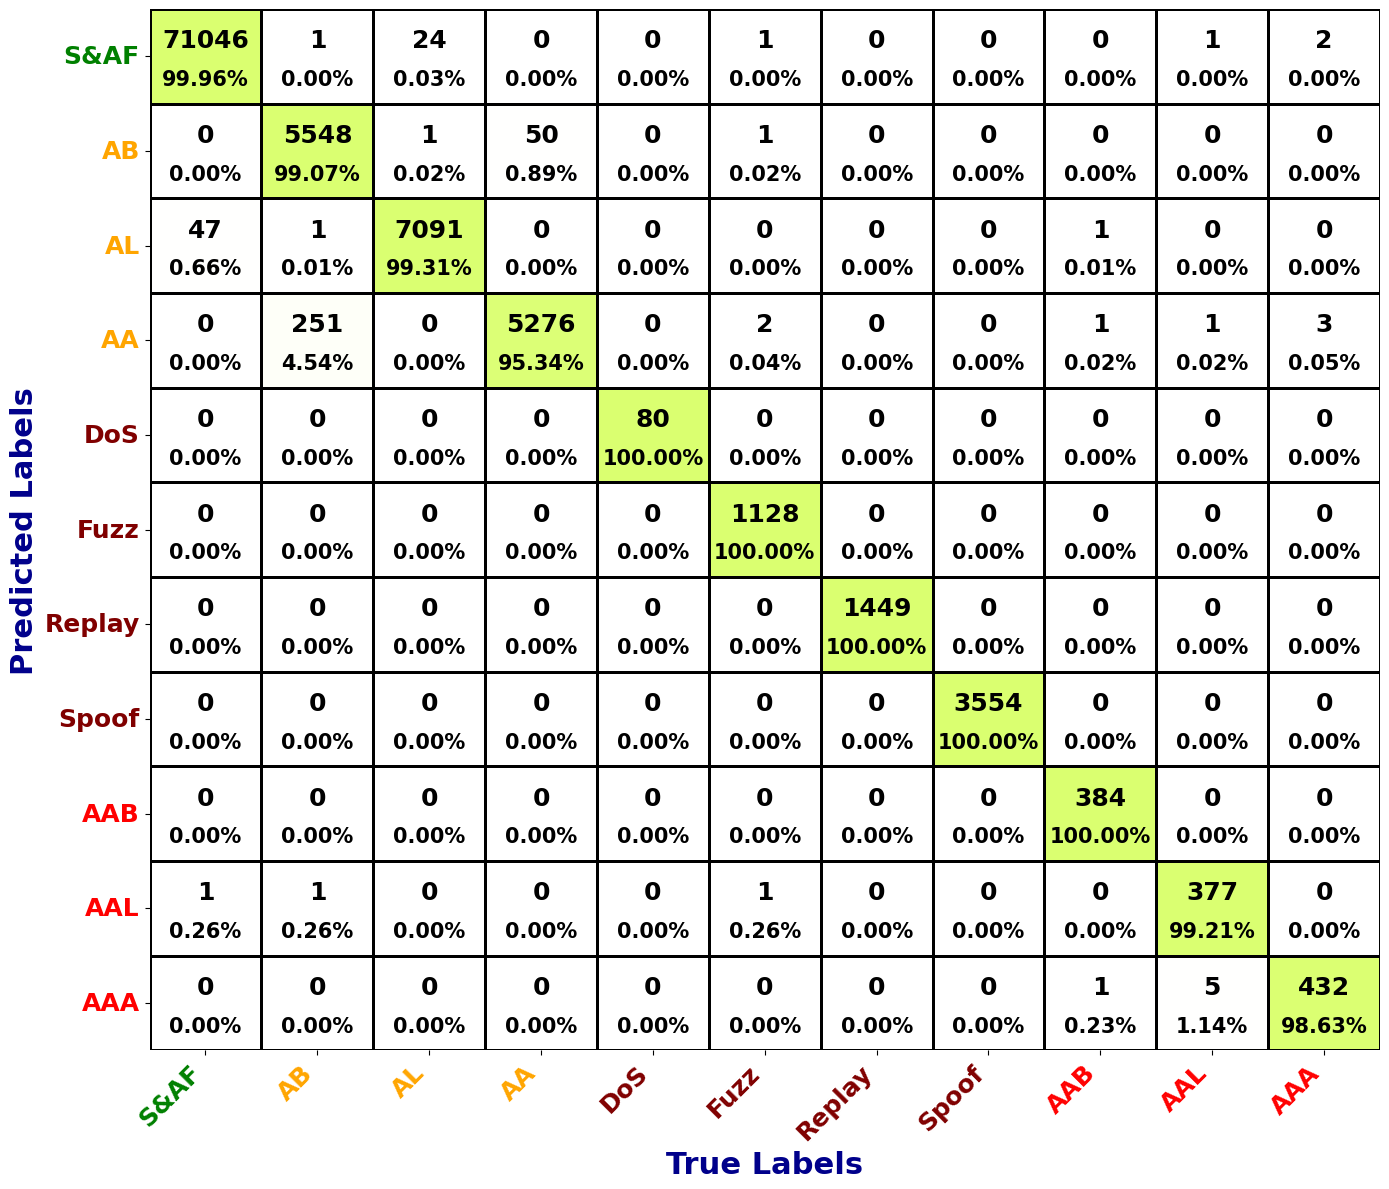

In [6]:
# --- Updated class labels --- #
class_labels = ["S&AF", "AB", "AL", "AA", "DoS", "Fuzz", "Replay", "Spoof", "AAB", "AAL", "AAA"]
PlotConfusionMatrixKia(cf_matrix, class_labels)

In [7]:
stats_df = ComputeFullMetrics(cf_matrix, class_labels)
stats_df

,Class,Support,Precision,Recall,F1,Accuracy,Error_Rate,CI_Lower,CI_Upper,AUC
0,S&AF,71075,0.9993,0.9996,0.9995,0.9996,0.0004,0.9994,0.9997,1.0
1,AB,5600,0.9562,0.9907,0.9732,0.9907,0.0093,0.9878,0.9929,1.0
2,AL,7140,0.9965,0.9931,0.9948,0.9931,0.0069,0.9909,0.9948,1.0
3,AA,5534,0.9906,0.9534,0.9716,0.9534,0.0466,0.9475,0.9586,1.0
4,DoS,80,1.0000,1.0000,1.0000,1.0000,0.0000,0.9542,1.0000,1.0
5,Fuzz,1128,0.9956,1.0000,0.9978,1.0000,0.0000,0.9966,1.0000,1.0
6,Replay,1449,1.0000,1.0000,1.0000,1.0000,0.0000,0.9974,1.0000,1.0
7,Spoof,3554,1.0000,1.0000,1.0000,1.0000,0.0000,0.9989,1.0000,1.0
8,AAB,384,0.9922,1.0000,0.9961,1.0000,0.0000,0.9901,1.0000,1.0
9,AAL,380,0.9818,0.9921,0.9869,0.9921,0.0079,0.9770,0.9973,1.0


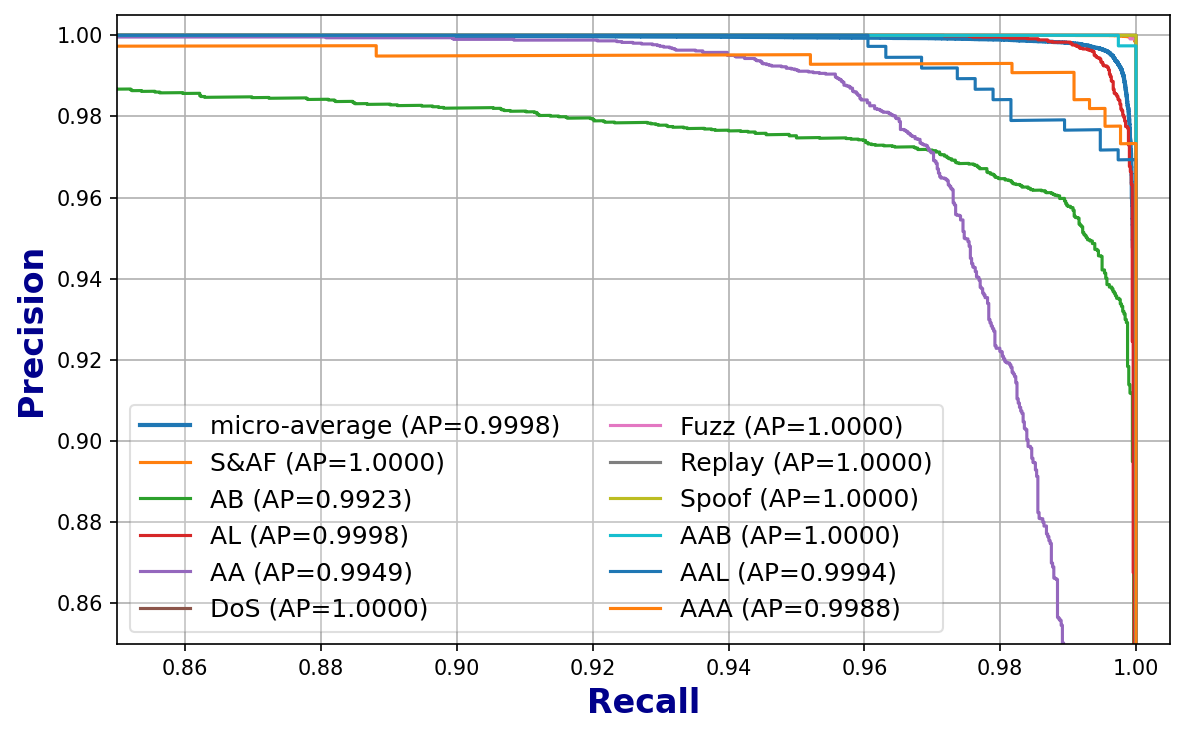

{'AP_micro': 0.9998359149367226,
 'AP_macro': 0.998662230046644,
 'AP_per_class': {'S&AF': 0.9999976179689076,
  'AB': 0.9923456108190174,
  'AL': 0.9998155660243754,
  'AA': 0.9949359881853791,
  'DoS': 0.9999999999999998,
  'Fuzz': 0.9999992147698646,
  'Replay': 1.0,
  'Spoof': 1.0,
  'AAB': 0.999993235930736,
  'AAL': 0.9993750768765236,
  'AAA': 0.9988222199382818}}

In [9]:
y_test, y_score = GetProbsAndLabels(model, test_loader, device)
PlotPRCurve(
    y_true=y_test,
    y_score=y_score,
    class_labels=["S&AF","AB","AL","AA","DoS","Fuzz","Replay","Spoof", "AAB","AAL","AAA"],
    xlim=(0.85, 1.005),
    ylim=(0.85, 1.005),
)